In [1]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def E_piecewise(m, E1_func, p_min):
    m = np.array(m)

    # Base efficiency
    E1 = E1_func(m)

    # Recursive construction
    E2 = E1 + np.sqrt(2)*E1 - np.sqrt(2)*(E1**2)
    E3 = E2 + np.sqrt(3)*E1 - np.sqrt(3)*E2*E1

    # Find thresholds numerically
    m1 = m[np.argmin(np.abs(E1 - p_min))]
    m2 = m[np.argmin(np.abs(E2 - p_min))]

    # Piecewise: 1 → 2 → 3 exposures
    E = np.where(m < m1, E1,
        np.where(m < m2, E2, E3)
    )

    return E, m1, m2

def n_pass(m, E1_func, m1, m2):
    """
    Compute <n_pass(m)> consistently with the exposure model.
    
    Parameters:
        m : array-like
        E1_func : function (single-exposure efficiency)
        m1, m2 : thresholds
    
    Returns:
        array-like
    """
    m = np.array(m)

    # Single-exposure efficiency
    E1 = E1_func(m)

    n = np.where(m < m1, 1,
        np.where(m < m2,
            1 + (1 - E1),
            1 + (1 - E1) + (1 - E1)*(1 - np.sqrt(2)*E1)
        )
    )

    return n

def E_wst_udrop_single_exp(m):
    return -0.18*m + 4.8

def E_wst_lbg_dropout(m_i, D_zu, D_zx, E_wst_udrop_single_exp, dropout_band = 'u'):
    """
    Parameters:
        m_i : float
            Input magnitude
        D_zu : float
            Growth factor D(z_u)
        D_zg : float
            Growth factor D(z_g)
        E_wst_udrop : function
            Function that takes magnitude and returns E_WST^udrop

    Returns:
        float : E_WST^gdrop
    """
    if not dropout_band == 'u':
        ratio = D_zu / D_zx
        shifted_m = m_i -5 * np.log10(ratio)
    else:
        ratio=1
        shifted_m = m_i
    
    return (ratio ** 2) * E_wst_udrop_single_exp(shifted_m)

# define a simple udrop function

0.2999999999999998


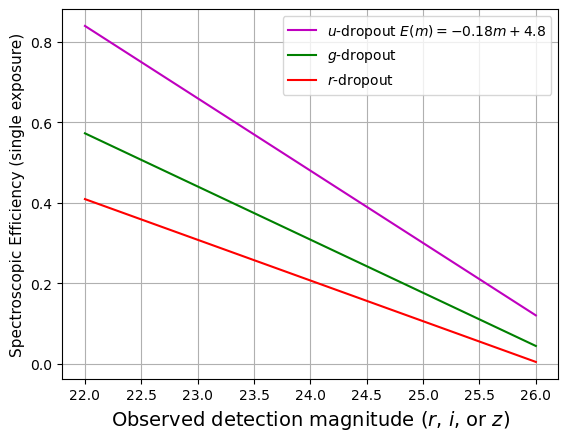

In [2]:
result = E_wst_lbg_dropout(m_i=25, D_zu=1.2, D_zx=1.0, E_wst_udrop_single_exp=E_wst_udrop_single_exp,  dropout_band = 'u')
print(result)
r_mag = np.linspace(22, 26, 10)
i_mag = np.linspace(22, 26, 10)
z_mag = np.linspace(22, 26, 10)
plt.plot(r_mag , E_wst_lbg_dropout(m_i=r_mag, D_zu=6, D_zx=6, E_wst_udrop_single_exp=E_wst_udrop_single_exp, dropout_band = 'u'), 'm', label = r'$u$-dropout $E(m) = -0.18m + 4.8$')
plt.plot(i_mag , E_wst_lbg_dropout(m_i=i_mag, D_zu=6, D_zx=7, E_wst_udrop_single_exp=E_wst_udrop_single_exp, dropout_band = 'g'), 'g', label = r'$g$-dropout')
plt.plot(z_mag , E_wst_lbg_dropout(m_i=z_mag, D_zu=6, D_zx=8, E_wst_udrop_single_exp=E_wst_udrop_single_exp, dropout_band = 'r'), 'r', label = r'$r$-dropout')
plt.grid()
plt.ylabel('Spectroscopic Efficiency (single exposure)', fontsize=11)
plt.xlabel('Observed detection magnitude ($r$, $i$, or $z$)', fontsize=14)
plt.legend()
#plt.savefig(f'spectroscopic_efficiency_LBG_ugr_single_exp.png', dpi = 300, bbox_inches='tight' )

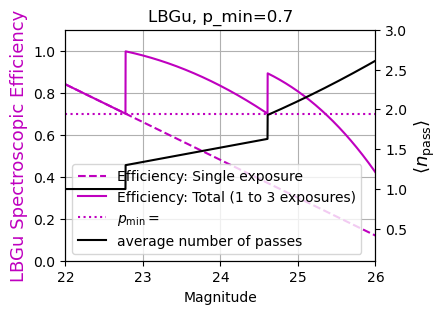

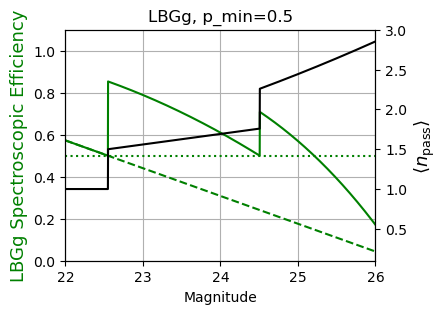

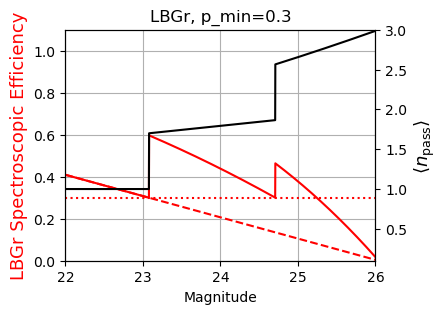

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(19., 26, 3400)

color = ['m', 'g', 'r']

p_min_list = [0.7, 0.5, 0.3]
Dz = [6,7,8]

for i, detection_band in enumerate(['u', 'g', 'r']):

    p_min = p_min_list[i]

    def E_single_exp_fct(m):
        return E_wst_lbg_dropout(m, Dz[0], Dz[i], E_wst_udrop_single_exp, dropout_band = detection_band)
    
    E_vals, m1, m2 = E_piecewise(m_vals, E_single_exp_fct, p_min)
    n_vals = n_pass(m_vals, E_single_exp_fct, m1, m2)
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=(4,3))
    ax1.set_title(f"LBG{detection_band}, p_min={p_min}")
    # --- Left axis: Efficiency ---
    ax1.plot(m_vals, E_single_exp_fct(m_vals), '--'+color[i], label="Efficiency: Single exposure")
    ax1.plot(m_vals, E_vals, color=color[i],  label="Efficiency: Total (1 to 3 exposures)")
    ax1.axhline(p_min, ls=':', color=color[i], label = r'$p_{\rm min} = $')
    
    ax1.set_xlabel("Magnitude")
    ax1.set_ylabel(f"LBG{detection_band} Spectroscopic Efficiency", color=color[i], fontsize=13)
    ax1.set_ylim(0, 1.1)
    ax1.set_xlim(22, 26)
    ax1.grid()
    
    # --- Right axis: Number of passes ---
    ax2 = ax1.twinx()
    #ax2.plot(m_vals, 1 + np.zeros(len(m_vals)), ls='--', color='blue', label=r'1 pass')
    ax2.plot(m_vals, n_vals, color='k', label=r'average number of passes')
    ax2.set_ylabel(r"$\langle n_{\rm pass} \rangle$", color='k', fontsize=13)
    ax2.set_ylim(0.1,3)
    
    # --- Combined legend (important trick) ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    if i==0:
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2,)
    
    #plt.tight_layout()
    #plt.savefig(f'spectroscopic_efficiency_LBG{detection_band}_dropout.png', dpi = 300, bbox_inches='tight' )